# Netflix Content Analysis

## Dataset

This project uses the Netflix Movies and TV Shows dataset.

The dataset includes information such as:
- Title
- Type (Movie or TV Show)
- Director
- Cast
- Country
- Release Year
- Rating
- Duration
- Genre (listed_in)
- Date added to Netflix

## Objective
Analyze Netflix content trends using Python.

## Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## Load Dataset

In [18]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
df.shape

(8807, 12)

In [20]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [22]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [23]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [27]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Data Cleaning

In this section we clean the dataset by handling missing values, fixing formatting issues, and creating new columns useful for analysis.

In [28]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [29]:
df['date_added'] = df['date_added'].str.strip()

In [30]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [31]:
df['year_added'] = df['date_added'].dt.year

In [32]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

In [33]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [34]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
year_added      10
dtype: int64

In [35]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

In [36]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [37]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [38]:
df['duration_int'] = df['duration'].str.extract('(\d+)')
df['duration_int'] = pd.to_numeric(df['duration_int'])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8797 non-null   float64       
 13  month_added   8797 non-null   float64       
 14  duration_int  8804 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int6

In [40]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      10
month_added     10
duration_int     3
dtype: int64

In [41]:
df = df.dropna(subset=['date_added', 'duration'])

In [42]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
duration_int    0
dtype: int64

## Exploratory Data Analysis

### Movies vs TV Shows

In [24]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

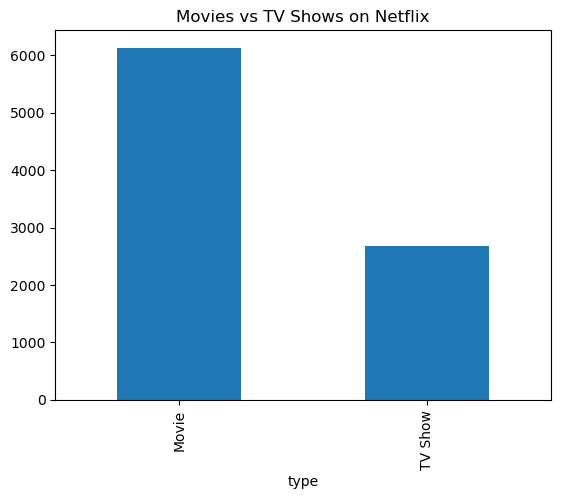

In [25]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

### Release Year Analysis

In [43]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     427
2017.0    1187
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

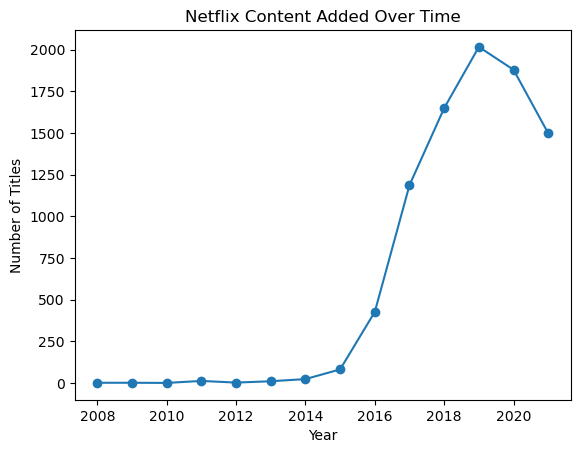

In [44]:
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Top Countries Producing Content

In [45]:
df['main_country'] = df['country'].str.split(',').str[0]

In [46]:
df['main_country'].value_counts().head(10)

main_country
United States     3202
India             1008
Unknown            830
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64

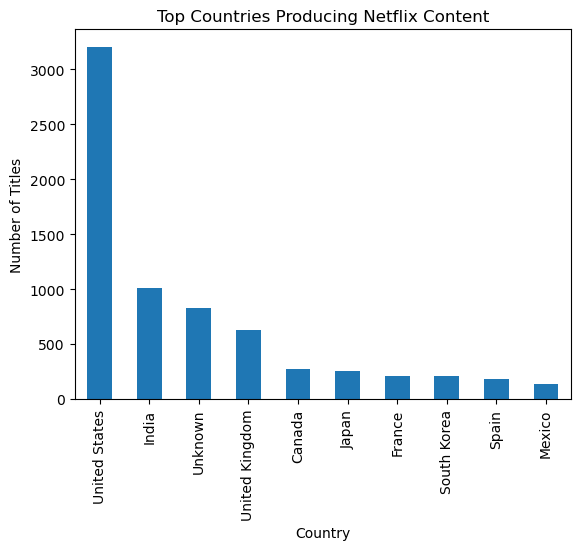

In [47]:
df['main_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [48]:
df['main_country'].value_counts().head(5)

main_country
United States     3202
India             1008
Unknown            830
United Kingdom     627
Canada             271
Name: count, dtype: int64

In [49]:
df['main_country'] = df['main_country'].replace('Unknown', 'Not Specified')

In [51]:
df_country = df[df['main_country'] != 'Unknown']

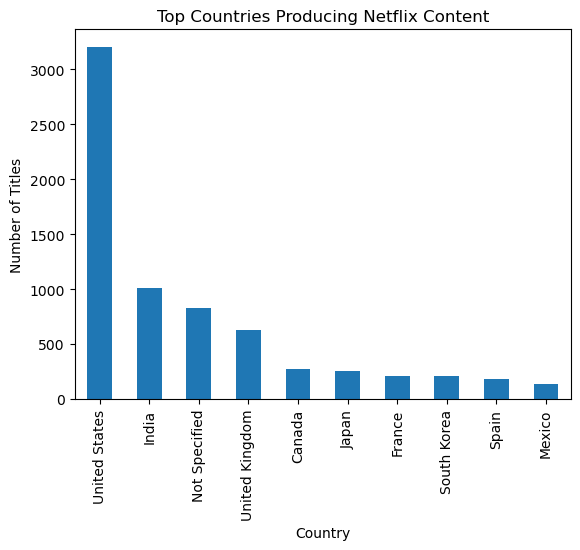

In [52]:
df_country['main_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [53]:
df_country = df[df['main_country'] != 'Unknown']

In [54]:
df_country['main_country'].value_counts().head(5)

main_country
United States     3202
India             1008
Not Specified      830
United Kingdom     627
Canada             271
Name: count, dtype: int64

In [55]:
df['main_country'] = df['main_country'].str.strip()

In [56]:
df_country = df[df['main_country'] != 'Unknown']

In [57]:
df_country['main_country'].value_counts().head(10)

main_country
United States     3202
India             1008
Not Specified      830
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64

In [58]:
df['main_country'].unique()

array(['United States', 'South Africa', 'Not Specified', 'India',
       'United Kingdom', 'Germany', 'Mexico', 'Turkey', 'Australia',
       'Finland', 'China', 'Nigeria', 'Japan', 'Spain', 'France',
       'Belgium', 'South Korea', 'Argentina', 'Russia', 'Canada',
       'Hong Kong', 'Italy', '', 'Ireland', 'New Zealand', 'Jordan',
       'Colombia', 'Switzerland', 'Israel', 'Brazil', 'Taiwan',
       'Bulgaria', 'Poland', 'Saudi Arabia', 'Thailand', 'Indonesia',
       'Egypt', 'Kuwait', 'Malaysia', 'Vietnam', 'Sweden', 'Lebanon',
       'Romania', 'Philippines', 'Iceland', 'Denmark',
       'United Arab Emirates', 'Netherlands', 'Norway', 'Syria',
       'Mauritius', 'Austria', 'Czech Republic', 'Cameroon', 'Uruguay',
       'Kenya', 'Chile', 'Luxembourg', 'Bangladesh', 'Portugal',
       'Hungary', 'Senegal', 'Singapore', 'Serbia', 'Namibia', 'Peru',
       'Mozambique', 'Belarus', 'Ghana', 'Zimbabwe', 'Puerto Rico',
       'Pakistan', 'Cyprus', 'Paraguay', 'Croatia', 'Cambodia', 

In [59]:
df['main_country'] = df['main_country'].str.strip()
df['main_country'] = df['main_country'].replace('Not Specified', None)

In [60]:
df_country = df.dropna(subset=['main_country'])

In [61]:
df_country['main_country'].value_counts().head(10)

main_country
United States     3202
India             1008
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Australia          116
Name: count, dtype: int64

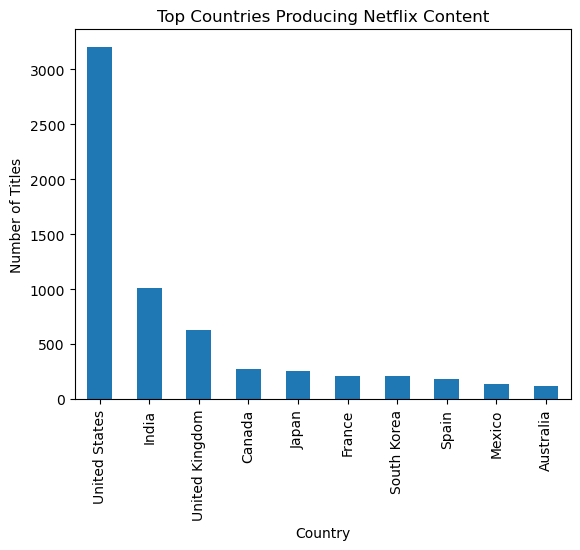

In [62]:
df_country['main_country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

### Most Common Genres

In [63]:
df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

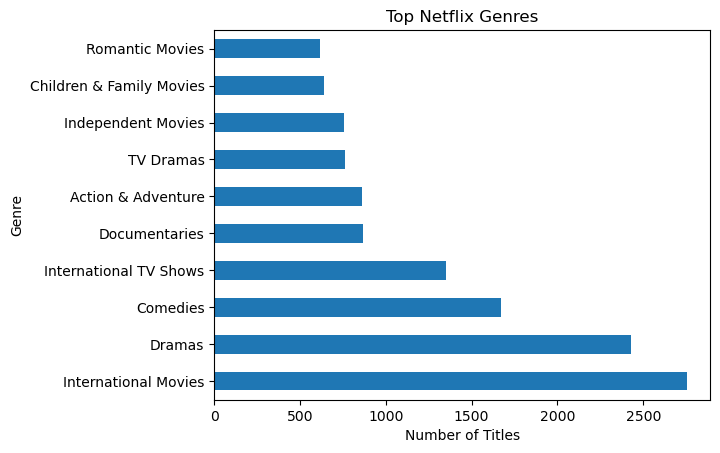

In [64]:
genre_counts = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)

genre_counts.plot(kind='barh')
plt.title("Top Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Content Rating Distribution

In [65]:
df['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

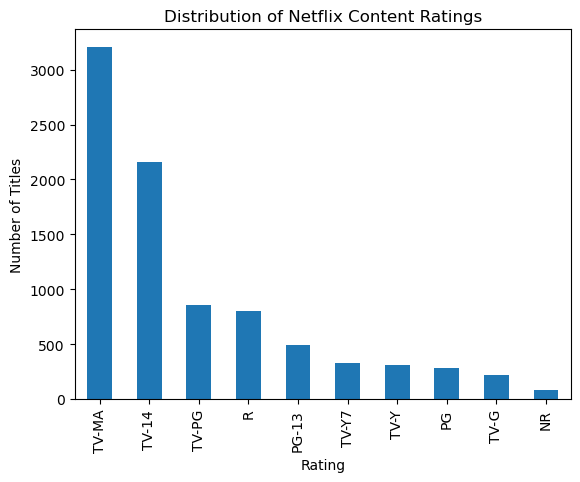

In [66]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()

### Movies vs TV Shows Distribution

In [67]:
pd.crosstab(df['year_added'], df['type'])

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,251,176


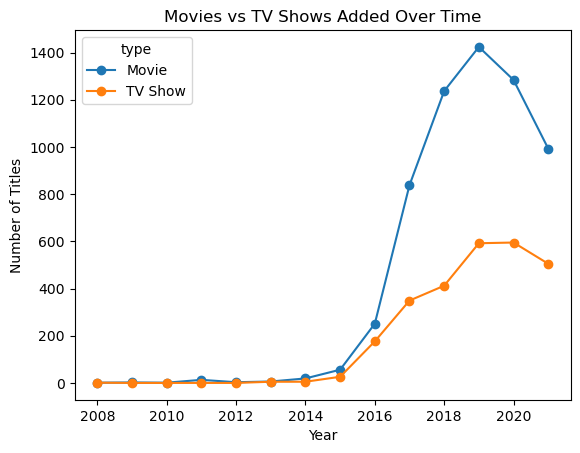

In [68]:
pd.crosstab(df['year_added'], df['type']).plot(kind='line', marker='o')
plt.title("Movies vs TV Shows Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Checking for Duplicate Titles
This analysis checks whether any titles appear multiple times in the dataset.

Duplicate titles may occur due to:
- Multiple seasons of the same show
- Remakes or different productions with the same name

The results show that almost all titles appear only once, indicating that the dataset primarily contains unique titles rather than repeated entries.

In [69]:
df['title'].value_counts().head(10)

title
Consequences                                        2
Dick Johnson Is Dead                                1
Care Bears & Cousins                                1
Pee-wee's Big Holiday                               1
Netflix Presents: The Characters                    1
Your lie in April                                   1
Crouching Tiger, Hidden Dragon: Sword of Destiny    1
Marvel Super Hero Adventures: Frost Fight!          1
Cooked                                              1
Hannibal Buress: Comedy Camisado                    1
Name: count, dtype: int64

## Key Insights

- Netflix has significantly more movies than TV shows.
- The platform experienced major catalog growth around 2018–2019.
- The United States and India are among the largest producers of Netflix content.
- International Movies and Dramas dominate the catalog.
- Most Netflix content targets adult and teen audiences.

## Conclusion

This analysis explored trends in Netflix's content library using Python. 
The results show Netflix's strong focus on global content, dramatic storytelling, and adult-oriented entertainment. 
The platform has grown rapidly over the past decade while expanding its international catalog.